# Modelización Matemática - Tema 1
## Diego Ángel Gallardo Costilla

### Preámbulo (Ejercicios 2.3 y 2.4)
Para comenzar, importaremos la librería **pandas** y procederemos a importar nuestra base de datos `PContexto.txt` fabricada en **ConExp**. Para hacerlo, nos valdremos del siguiente script, modificado para convertir los nombres de los objetos:

In [1]:
import pandas as pd

#Convertimos el archivo.txt a .csv
read_file = pd.read_csv ('PContexto.txt', delimiter = '\t')
read_file.to_csv ('PContexto.csv', index=False, sep = ';')

In [2]:
#Convertimos el archivo .csv a dataframe (para poder manipularlo y añadir la etiqueta de los objetos)
df = pd.read_csv ('PContexto.csv', sep = ';') 

#Eliminamos la útlima columna de la tabla (dado que contiene NaN)
df = df.drop(df.columns[df.shape[1]-1], axis=1)


#Definimos el nombre que le queremos dar a cada objeto (que se corresponde con las fila de nuestro nuevo dataframe).
#objetos =[]
#for i in range(0,df.shape[0]):
#    objetos.append('Obj '+ str(i+1))
    
#Otra posibilidad es introducir a mano el nombre de los objetos como:
objetos =["Special Week","Silence Suzuka","Daiwa Scarlet","Vodka","Gold Ship","Mejiro McQueen","Tokai Teio","Symboli Rudolf","Biwa Hayahide","Narita Brian","Eishin Flash","Hishi Akebono","Tamamo Cross","Haru Urara","Oguri Cap"]

#Insertamos el nombre de los objetos por cada fila
df.insert(0, "", objetos, True) 

#Volvemos a convertir el dataframe en archivo .csv
df.to_csv('ContextoLimpio.csv', index=False, sep=';')

Una vez convertida y nombrada `ContextoLimpio.csv`, es hora de leerla con **pandas** y asignarle `df` para poder trabajar con ella en los siguientes ejercicios.

In [3]:
df = pd.read_csv("ContextoLimpio.csv", sep=";", index_col=0)

Esta base de datos contiene información sobre caballos de carreras japoneses: sus aptitudes de pista, longitudes, estilos de carrera y destrezas. Para la comprensión del lector, "Turf" y "Dirt" son sus aptitudes de pista, las cuatro longitudes van de "Sprint" a "Long", los cuatro estilos van de "End Closer" a "Front Runner" y los últimos cinco atributos son sus destrezas.

In [4]:
df

,Turf,Dirt,Sprint,Mile,Medium,Long,End Closer,Late Surger,Pace Chaser,Front Runner,Speed Bonus,Stamina Bonus,Power Bonus,Guts Bonus,Wit Bonus
Special Week,1,0,0,0,1,1,0,1,1,0,0,1,0,0,1
Silence Suzuka,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0
Daiwa Scarlet,1,0,0,1,1,0,0,0,1,1,1,0,0,1,0
Vodka,1,0,0,1,1,0,0,1,1,0,1,0,0,0,0
Gold Ship,1,0,0,0,1,1,1,1,1,0,0,1,1,0,0
Mejiro McQueen,1,0,0,0,1,1,0,0,1,0,0,1,0,0,1
Tokai Teio,1,0,0,0,1,1,0,0,1,0,1,1,0,1,0
Symboli Rudolf,1,0,0,0,1,1,0,1,1,0,0,1,0,1,0
Biwa Hayahide,1,0,0,0,1,1,0,1,1,0,0,0,0,1,1
Narita Brian,1,0,0,1,1,1,0,1,1,0,1,1,0,0,0


In [5]:
#El número de filas se nos determinará como df.shape[0], y el número de columnas como df.shape[1]. Veamos el nombre de los objetos:
print(df.index)

Index(['Special Week', 'Silence Suzuka', 'Daiwa Scarlet', 'Vodka', 'Gold Ship',
       'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide',
       'Narita Brian', 'Eishin Flash', 'Hishi Akebono', 'Tamamo Cross',
       'Haru Urara', 'Oguri Cap'],
      dtype='object')


In [6]:
print(df.iloc[2,0])
print(df.loc["Daiwa Scarlet","Turf"])

1
1


In [7]:
df_ext = df[(df["Turf"] == 1) & (df["Mile"] == 1) & (df["Guts Bonus"] == 1)]
df_ext

,Turf,Dirt,Sprint,Mile,Medium,Long,End Closer,Late Surger,Pace Chaser,Front Runner,Speed Bonus,Stamina Bonus,Power Bonus,Guts Bonus,Wit Bonus
Silence Suzuka,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0
Daiwa Scarlet,1,0,0,1,1,0,0,0,1,1,1,0,0,1,0
Hishi Akebono,1,0,1,1,0,0,0,0,1,1,0,0,1,1,0


### Ejercicio 2.6

Sea $(\mathcal{O}, \mathcal{P}, \mathcal{R})$ nuestro contexto, expresado como DataFrame. A continuación, definiremos la **extensión** de un subconjunto $A \subseteq \mathcal{P}$ como operador de derivación en Python. En efectos prácticos, si introducimos una lista de atributos, nos devolverá los objetos que posean todos esos atributos a la vez.

In [8]:
def extension(df, atributos):
    """Dado un DataFrame y una lista de atributos, 
    devuelve solo los objetos que poseen 
    todos los atributos especificados."""
    if not atributos:
        return df.index.tolist()
    for atributo in atributos:
        if atributo in df.columns:
            df = df[df[atributo] == 1]
        else:
            print(f"El atributo '{atributo}' no se encuentra en el DataFrame.")
    return df.index.tolist()

Pongamos un ejemplo: queremos saber qué caballos corren en "Turf", a distancia "Mile" y se categorizan con "Guts Bonus". Usando la nueva función, los resultados concuerdan con la base de datos:

In [9]:
atributos = ["Turf", "Mile", "Guts Bonus"]
objetos_con_atributos = extension(df, atributos)
print(objetos_con_atributos)

['Silence Suzuka', 'Daiwa Scarlet', 'Hishi Akebono']


En **ConExp**, vemos que coinciden los resultados (el nodo que se encuentra más al sur es la extensión del conjunto):

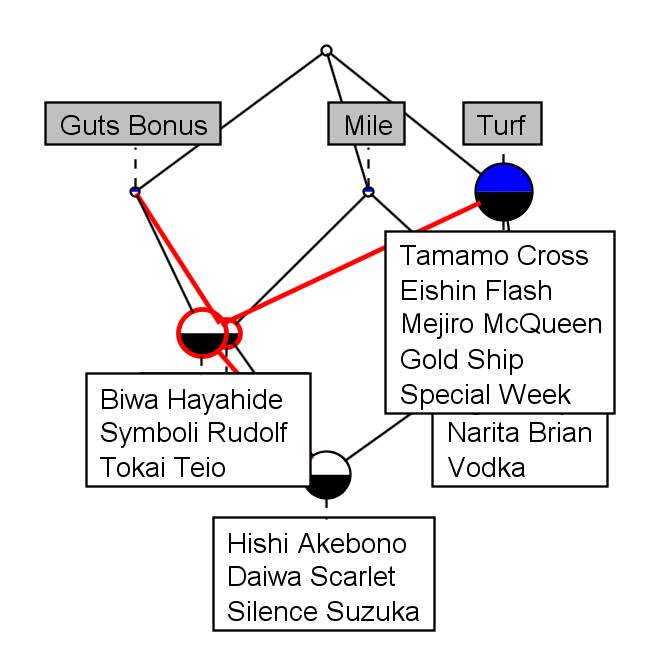

Ahora definiremos de forma similar el operador de derivación conocido como **intensión**, aplicado sobre un subconjunto $A \subseteq \mathcal{O}$. Si le introducimos una lista de objetos, nos devolverá los atributos que poseen todos en común.

In [10]:
def intension(df, objetos):
    """Dado un DataFrame y una lista de objetos, 
    devuelve solo los atributos que todos los objetos 
    especificados poseen."""
    filasobjetos = []
    for objeto in objetos:
        if objeto in df.index:
            # Extrae la fila completa del objeto y la añade a la lista de filasobjetos
            filasobjetos.append(df.loc[df.index == objeto])
        else:
            print(f"El objeto '{objeto}' no se encuentra en el DataFrame.")
    if not filasobjetos:
        return df.columns.tolist()  # Si no se encontraron objetos, devolvemos todos los atributos
    # Concatenamos todas las filas de filasobjetos en un solo DataFrame
    dfobj = pd.concat(filasobjetos)
    # Seleccionamos solo las columnas donde todos los valores son 1, es decir, los atributos comunes a todos los objetos
    atributos_comunes = dfobj.columns[(dfobj == 1).all()]
    return atributos_comunes.tolist()

Ahora, pongamos que queremos saber qué características de nuestra base de datos comparten "Gold Ship" y "Haru Urara". Al introducir la lista de nombres, obtendremos el resultado esperado.

In [11]:
objetos = ["Gold Ship", "Haru Urara"]
atributos_comunes = intension(df, objetos)
print(atributos_comunes)

['End Closer', 'Late Surger', 'Power Bonus']


Al comparar los resultados en **ConExp**, vemos que coinciden de forma satisfactoria (el nodo más al norte es la intensión).

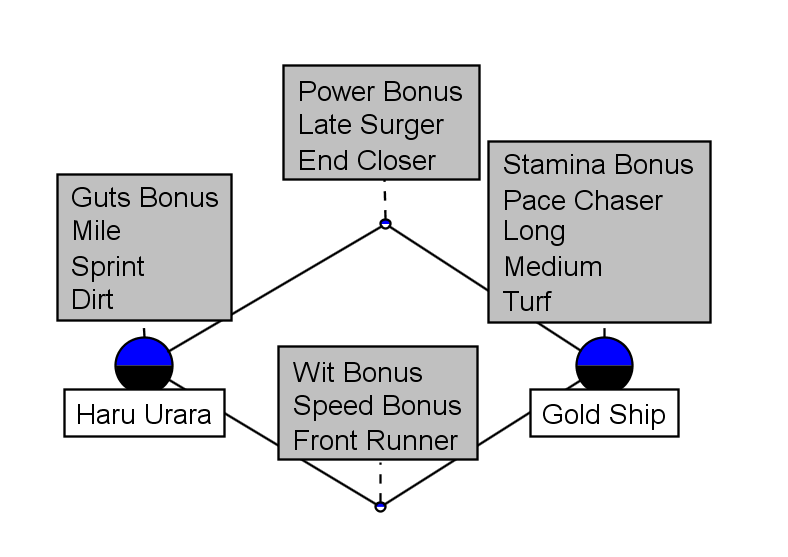

### Ejercicio 2.9

Ahora, comprobaremos si la composición de ambos operadores por ambos sentidos (por simplicidad consideremos a cualquiera de los dos como $c$) es un operador de clausura. Primero, definamos `intext` y `extint` como ambos sentidos de la composición. `intext` primero realiza la intensión y después la extensión, y `extint` viceversa.

In [12]:
def intext(df, objetos):
    return extension(df, intension(df, objetos))
def extint(df, atributos):
    return intension(df, extension(df, atributos))

Tomamos la relación de orden $\subseteq$ como la inclusión de conjuntos; para ver que `intext` y `extint` son crecientes, tomemos dos listas $l_i, l_ip$ tales que $l_i \subseteq l_ip$ y veamos que se mantiene $c(l_i) \subseteq c(l_ip)$:

In [13]:
l1 = ["Daiwa Scarlet", "Vodka"]
l1p = ["Daiwa Scarlet", "Vodka", "Haru Urara"]
l2 = ["Turf", "Long"]
l2p = ["Turf", "Long", "Guts Bonus"]
print(f"Realizamos la operación de extensión de la intensión de {l1} y {l1p}:")
print(f"Bien, se ve que {intext(df, l1)} está contenida en {intext(df, l1p)}")
print(f"Realizamos la operación de intensión de la extensión de {l2} y {l2p}:")
print(f"A su vez, se observa que {extint(df, l2)} está contenida en {extint(df, l2p)}")

Realizamos la operación de extensión de la intensión de ['Daiwa Scarlet', 'Vodka'] y ['Daiwa Scarlet', 'Vodka', 'Haru Urara']:
Bien, se ve que ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap'] está contenida en ['Silence Suzuka', 'Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Hishi Akebono', 'Haru Urara', 'Oguri Cap']
Realizamos la operación de intensión de la extensión de ['Turf', 'Long'] y ['Turf', 'Long', 'Guts Bonus']:
A su vez, se observa que ['Turf', 'Medium', 'Long', 'Pace Chaser'] está contenida en ['Turf', 'Medium', 'Long', 'Pace Chaser', 'Guts Bonus']


Comprobamos, usando esas mismas listas, que ambas cumplen que $x \subseteq c(x)$:

In [14]:
print(f"Se ve que {l1} está contenida en {intext(df, l1)}")
print(f"Se ve que {l2} está contenida en {extint(df, l2)}")

Se ve que ['Daiwa Scarlet', 'Vodka'] está contenida en ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap']
Se ve que ['Turf', 'Long'] está contenida en ['Turf', 'Medium', 'Long', 'Pace Chaser']


Por último, comprobemos que $c(c(x)) = c(x)$ de las dos formas:

In [15]:
cl1 = intext(df, l1)
cl2 = extint(df, l2)
ccl1 = intext(df, cl1)
ccl2 = extint(df, cl2)
print(f"Se ve que {cl1} es igual a {ccl1}")
print(f"Se ve que {cl2} es igual a {ccl2}")

Se ve que ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap'] es igual a ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap']
Se ve que ['Turf', 'Medium', 'Long', 'Pace Chaser'] es igual a ['Turf', 'Medium', 'Long', 'Pace Chaser']


### Ejercicio 2.10

Comprobemos que $\uparrow\downarrow$ y $\downarrow\uparrow$ son operadores de clausura. Veamos que ambas aplicaciones son crecientes; tomemos $x_1, x_2 \in P_2$ tales que $x_1 \leq_1 x_2$. Efectivamente, como $\uparrow$ es decreciente, $x_2^{\uparrow} \leq_2 x_1^{\uparrow}$, y como $\downarrow$ es decreciente, $x_1^{\uparrow\downarrow} \leq_1 x_2^{\uparrow\downarrow}$ (el razonamiento es análogo para $\downarrow\uparrow$). Que $x \leq_1 x^{\uparrow\downarrow}$ o su caso análogo es trivial por ser conexiones de Galois. Ahora, veamos que son idempotentes. Como $x \leq_1 x^{\uparrow\downarrow}$, se cumple que $x^{\uparrow\downarrow} \leq_1 (x^{\uparrow\downarrow})^{\uparrow\downarrow}$. Ahora bien, por la propiedad 2 se tiene que $x^{\uparrow} \leq_2 x^{\uparrow\downarrow\uparrow}$, y al ser $\downarrow$ decreciente, se tendrá pues que $x^{\uparrow\downarrow\uparrow\downarrow} \leq_1  x^{\uparrow\downarrow}$, como queríamos. De nuevo, el razonamiento es análogo para $\downarrow\uparrow$.$$\blacksquare$$

### Ejercicio 2.12
Procedamos a comprobar las propiedades del Lema 2.11. Para **1.** $X \subseteq X''$, $A \subseteq A''$, tomemos dos conjuntos en $\mathcal{O}$ y $\mathcal{P}$ y usemos las funciones `extint` y `intext` programadas anteriormente:

In [16]:
X = ["Daiwa Scarlet", "Vodka"]
A = ["Turf", "Long"]
print(f"Se ve que {X} está contenida en {intext(df, X)}")
print(f"Se ve que {A} está contenida en {extint(df, A)}")

Se ve que ['Daiwa Scarlet', 'Vodka'] está contenida en ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap']
Se ve que ['Turf', 'Long'] está contenida en ['Turf', 'Medium', 'Long', 'Pace Chaser']


**2.** Si $X_1 \subseteq X_2$, entonces $X_2' \subseteq X_1'$. Veamos:

In [17]:
X1 = ["Daiwa Scarlet", "Vodka"]
X2 = ["Daiwa Scarlet", "Vodka", "Haru Urara"]
X2p = intension(df, X2)
X1p = intension(df, X1)
print(f"Se ve que {X2p} está contenida en {X1p}")

Se ve que ['Mile'] está contenida en ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Speed Bonus']


Análogamente, si $A_1 \subseteq A_2$, entonces $A_2' \subseteq A_1'$.

In [18]:
A1 = ["Turf", "Long"]
A2 = ["Turf", "Long", "Wit Bonus"]
A2p = extension(df, A2)
A1p = extension(df, A1)
print(f"Se ve que {A2p} está contenida en {A1p}")

Se ve que ['Special Week', 'Mejiro McQueen', 'Biwa Hayahide', 'Eishin Flash'] está contenida en ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross']


**3.** $X' = X'''$, $A' = A'''$. Usando los conjuntos del anterior:

In [19]:
print(f"{X1p} es igual a {extint(df, X1p)}")
print(f"A su vez, {A1p} es igual a {intext(df, A1p)}")

['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Speed Bonus'] es igual a ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Speed Bonus']
A su vez, ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross'] es igual a ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross']


**4.** $\left( \bigcup_{j \in J} X_j \right)' = \bigcap_{j \in J} X_j'$, $\left( \bigcup_{j \in J} A_j \right)' = \bigcap_{j \in J} A_j'$.

Primero, investiguemos cómo realizar intersecciones y uniones de listas.

In [20]:
x1 = ["Gold Ship", "Mejiro McQueen"]
x2 = ["Mejiro McQueen", "Daiwa Scarlet"]
x3 = ["Gold Ship", "Daiwa Scarlet", "Vodka"]
#La intersección de listas en Python se puede realizar mediante la función set() y el operador &:
int1 = list(set(x1) & set(x2))
int2 = list(set(x1) & set(x3))
int3 = list(set(x2) & set(x3))
print(f"La intersección de 1 y 2 es: {int1}")
print(f"La intersección de 1 y 3 es: {int2}")
print(f"La intersección de 2 y 3 es: {int3}")
# La unión de listas se puede realizar mediante el operador |:
union = list(set(x1) | set(x2) | set(x3))
print(f"Esta es la unión de las tres listas: {union}")

La intersección de 1 y 2 es: ['Mejiro McQueen']
La intersección de 1 y 3 es: ['Gold Ship']
La intersección de 2 y 3 es: ['Daiwa Scarlet']
Esta es la unión de las tres listas: ['Mejiro McQueen', 'Vodka', 'Gold Ship', 'Daiwa Scarlet']


Ahora, comprobemos la propiedad:

In [21]:
du = intension(df, union)
dx1 = intension(df, x1)
dx2 = intension(df, x2)
dx3 = intension(df, x3)
intd = list(set(dx1) & set(dx2) & set(dx3))
print(f"La propiedad se cumple: {intd} es igual a {du}.")

La propiedad se cumple: ['Medium', 'Turf', 'Pace Chaser'] es igual a ['Turf', 'Medium', 'Pace Chaser'].


Usando conjuntos de atributos en $\mathcal{P}$ y `extension`, se dará de forma análoga la segunda propiedad.

**5.** $X \subseteq A'$ si y sólo si $A \subseteq X'$.

Para la primera dirección, tomemos un conjunto $A \subseteq \mathcal{O}$ y un conjunto $X \subseteq \mathcal{P}$ tal que $X \subseteq A'$.

In [22]:
A = ["Biwa Hayahide", "Narita Brian"]
Ap = intension(df, A)
X = ["Turf", "Medium", "Long", "Pace Chaser"]
Xp = extension(df, X)
print(f"Bien, tomamos {X}, que está contenido en {Ap}")
print(f"Realizamos su extensión y obtenemos {Xp}.")
print(f"Se observa entonces que {A} está contenida en {Xp}")

Bien, tomamos ['Turf', 'Medium', 'Long', 'Pace Chaser'], que está contenido en ['Turf', 'Medium', 'Long', 'Late Surger', 'Pace Chaser']
Realizamos su extensión y obtenemos ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross'].
Se observa entonces que ['Biwa Hayahide', 'Narita Brian'] está contenida en ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross']


La segunda dirección será idéntica: tomamos un conjunto $X \subseteq \mathcal{P}$ y un conjunto $A \subseteq \mathcal{O}$ tal que $A \subseteq X'$.

In [23]:
X = ["Turf", "Mile"]
Xp = extension(df, X)
A = ["Hishi Akebono", "Oguri Cap"]
Ap = intension(df, A)
print(f"Bien, tomamos {A}, que está contenido en {Xp}")
print(f"Realizamos su intensión y obtenemos {Ap}.")
print(f"Se observa entonces que {X} está contenida en {Ap}")

Bien, tomamos ['Hishi Akebono', 'Oguri Cap'], que está contenido en ['Silence Suzuka', 'Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Hishi Akebono', 'Oguri Cap']
Realizamos su intensión y obtenemos ['Turf', 'Mile', 'Pace Chaser', 'Power Bonus'].
Se observa entonces que ['Turf', 'Mile'] está contenida en ['Turf', 'Mile', 'Pace Chaser', 'Power Bonus']


### Ejercicio 2.13

Queremos ver si $\left( \bigcap_{j \in J} X_j \right)' = \bigcup_{j \in J} X_j'$. De nuevo, reutilizamos las listas del apartado **4.**.

In [24]:
inttotal = list(set(x1) & set(x2) & set(x3))
inttotald = intension(df, inttotal)
unionder = list(set(dx1) | set(dx2) | set(dx3))
print(f"Se observa que la intersección de las tres listas es {inttotal}, y su intensión es el conjunto completo.")
print(f"Se observa que la unión de las intensiones de las tres listas es {unionder}; NO es el conjunto completo.")

Se observa que la intersección de las tres listas es [], y su intensión es el conjunto completo.
Se observa que la unión de las intensiones de las tres listas es ['Medium', 'Long', 'Pace Chaser', 'Stamina Bonus', 'Turf']; NO es el conjunto completo.


### Ejercicio 2.17
Para este ejercicio, se nos solicita trabajar con el contexto $(\mathcal{O}, \mathcal{P}, \mathcal{R)}$ del Ejemplo 2.2. Para poder hacerlo en Python, necesitamos importarlo como archivo `.csv`. En la carpeta se halla el documento `EjemploPeces.txt`, y mediante una rápida modificación del **Script-txtConexp-csvPython** para poder conservar los índices, convertimos el contexto y lo importamos como `PecesLimpio.csv`.

In [25]:
dfpeces = pd.read_csv("PecesLimpio.csv", sep=";", index_col=0)
dfpeces

,fluvial,litoral,oceano
carpa,1,0,0
escatofagus,1,1,0
sargo,0,1,1
dorada,0,1,1
anguila,1,1,1


Tras importar nuestro contexto, se nos solicita encontrar los conceptos contenidos. Esto es, encontrar los pares $(X,A)$ con $X \subseteq \mathcal{O}$ y $A \subseteq \mathcal{P}$ tales que $X' = A$ y $A' = X$. Ahora bien, comprobando manualmente y siguiendo la notación del documento, para el contexto $(\mathcal{O}, \mathcal{P}, \mathcal{R})$, tenemos los siguientes conceptos:
$$
\begin{aligned}
C_1 &= (\mathcal{O}, \emptyset) \\
C_2 &= (\{\text{carpa, escatofagus, anguila}\}, \{\text{fluvial}\}) \\
C_3 &= (\{\text{escatofagus, sargo, dorada, anguila}\}, \{\text{litoral}\}) \\
C_4 &= (\{\text{escatofagus, anguila}\}, \{\text{fluvial, litoral}\}) \\
C_5 &= (\{\text{sargo, dorada, anguila}\}, \{\text{litoral, océano}\}) \\
C_6 &= (\{\text{anguila}\}, \{\text{fluvial, litoral, océano}\})
\end{aligned}
$$

### Ejercicio 2.21
Observamos que $C_6 = (\{\text{anguila}\}, \{\text{fluvial, litoral, océano}\})$ se puede generar intersecando los objetos de $C_2$ y $C_5$ (sabiendo que la intersección de objetos es cerrada para conceptos), y realizando la intensión de este conjunto. Como se demostró en el Teorema 2.18, este es considerado el **ínfimo** de ambos conjuntos. El **supremo** de otros conceptos se puede obtener intersecando los atributos: por ejemplo, la intersección de los conjuntos $A_2 = \{\text{fluvial}\}$ en $C_2$ y $A_4 = \{\text{fluvial, litoral}\}$ en $C_4$ es $A_2$. Por tanto, el ínfimo de $C_2$ y $C_4$ es el propio $C_2$.

### Ejercicio 2.26
Hemos de programar las funciones $\gamma$ (objeto concepto) y $\mu$ (atributo concepto). Para ello, nos valdremos de las anteriores funciones de composición que definimos en ejercicios anteriores, `intext` y `extint`, para agrupar mejor el código.

In [26]:
def gamma(df,objeto):
    '''Devuelve el concepto generado
    por el objeto.'''
    x = intext(df,objeto)
    a = intension(df,objeto)
    return [x,a]

In [27]:
def mu(df,atributo):
    '''Devuelve el concepto generado
    por el atributo.'''
    x = extint(df,atributo)
    a = extension(df,atributo)
    return [x,a]

Probemos las dos funciones con un ejemplo sensillo.

In [28]:
objeto = ["Daiwa Scarlet"]
atributo = ["Dirt"]
print(f"El concepto generado por el objeto {objeto} es: {gamma(df, objeto)}")
print(f"El concepto generado por el atributo {atributo} es: {mu(df, atributo)}")
print(f"Por poner un ejemplo, se comprueba que {gamma(df, objeto)[1]} es {intension(df, gamma(df, objeto)[0])}.")

El concepto generado por el objeto ['Daiwa Scarlet'] es: [['Daiwa Scarlet'], ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Front Runner', 'Speed Bonus', 'Guts Bonus']]
El concepto generado por el atributo ['Dirt'] es: [['Dirt', 'Mile', 'Late Surger', 'Power Bonus'], ['Haru Urara', 'Oguri Cap']]
Por poner un ejemplo, se comprueba que ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Front Runner', 'Speed Bonus', 'Guts Bonus'] es ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Front Runner', 'Speed Bonus', 'Guts Bonus'].


In [29]:
def algoritmo(df):
    '''Dado un contexto, devuelve todos sus conceptos.'''
    # Empezamos definiendo el primer concepto, el formado por todos los objetos y los atributos comunes a todos ellos
    # A partir de ahí, se van generando nuevos conceptos a partir de los atributos con mayor extensión, y así sucesivamente
    objetos = set(df.index.tolist())
    listext = [objetos]
    conceptos = []

    # Ahora, vamos a hacer todas las extensiones de los atributos, y a partir de ahí, generar nuevos conceptos a partir de la intersección de los objetos que forman cada extensión, y la intensión de esa intersección.
    for atributo in df.columns:
        listext.append(set(extension(df, [atributo])))
    # intersecciones entre las extensiones de los atributos
    for ext1 in listext:
        for ext2 in listext:
            if ext1 != ext2:
                interseccion = ext1 & ext2
                if interseccion not in listext:
                    listext.append(interseccion)
    listext = [list(x) for x in listext]
    for obj in listext:
        conceptos.append([obj, intension(df, obj)])
    return conceptos

In [30]:
algoritmo(dfpeces)

[[['dorada', 'carpa', 'sargo', 'escatofagus', 'anguila'], []],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'dorada', 'escatofagus', 'sargo'], ['litoral']],
 [['anguila', 'dorada', 'sargo'], ['litoral', 'oceano']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']],
 [['anguila'], ['fluvial', 'litoral', 'oceano']]]

### Ejercicio 2.41
Primero, observemos que el número de conceptos en nuestro PContexto habitual es 61.

In [32]:
len(algoritmo(df))

61

Ahora, definamos un nuevo PContexto sin los dos primeros atributos (Turf y Dirt):

In [33]:
# DataFrame sin los dos primeros atributos
dfsin2p = df.drop(columns=df.columns[:2])
dfsin2p

,Sprint,Mile,Medium,Long,End Closer,Late Surger,Pace Chaser,Front Runner,Speed Bonus,Stamina Bonus,Power Bonus,Guts Bonus,Wit Bonus
Special Week,0,0,1,1,0,1,1,0,0,1,0,0,1
Silence Suzuka,0,1,1,0,0,0,0,1,1,0,0,1,0
Daiwa Scarlet,0,1,1,0,0,0,1,1,1,0,0,1,0
Vodka,0,1,1,0,0,1,1,0,1,0,0,0,0
Gold Ship,0,0,1,1,1,1,1,0,0,1,1,0,0
Mejiro McQueen,0,0,1,1,0,0,1,0,0,1,0,0,1
Tokai Teio,0,0,1,1,0,0,1,0,1,1,0,1,0
Symboli Rudolf,0,0,1,1,0,1,1,0,0,1,0,1,0
Biwa Hayahide,0,0,1,1,0,1,1,0,0,0,0,1,1
Narita Brian,0,1,1,1,0,1,1,0,1,1,0,0,0


Muy bien, el número de conceptos ahora será:

In [34]:
len(algoritmo(dfsin2p))

58

Observamos que el número de conceptos se ha visto reducido; debe de ser que alguno de nuestros dos atributos (o los dos) es absolutamente necesario para generar la misma cantidad de conceptos. Ahora, en el contexto de los peces, estos son los conceptos:

In [35]:
algoritmo(dfpeces)

[[['dorada', 'carpa', 'sargo', 'escatofagus', 'anguila'], []],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'dorada', 'escatofagus', 'sargo'], ['litoral']],
 [['anguila', 'dorada', 'sargo'], ['litoral', 'oceano']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']],
 [['anguila'], ['fluvial', 'litoral', 'oceano']]]

Quitémosle el atributo "océano", y observamos que obtenemos dos conceptos menos.

In [37]:
algoritmo(dfpeces.drop(columns="oceano"))

[[['dorada', 'carpa', 'sargo', 'escatofagus', 'anguila'], []],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'dorada', 'escatofagus', 'sargo'], ['litoral']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']]]

In [38]:
# Y si eliminamos el objeto "sargo":
algoritmo(dfpeces.drop(index="sargo"))

[[['anguila', 'carpa', 'escatofagus', 'dorada'], []],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'dorada', 'escatofagus'], ['litoral']],
 [['anguila', 'dorada'], ['litoral', 'oceano']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']],
 [['anguila'], ['fluvial', 'litoral', 'oceano']]]

El objeto "sargo" era absolutamente innecesario, ya que se han generado los mismos conceptos y el retículo es isomorfo al original.